## Load modules

In [59]:
import numpy as np
import cupy as cp
import time

import matplotlib.pyplot as plt
import pandas as pd

## Check GPU property

In [17]:
# Check for GPU availability
num_gpus = cp.cuda.runtime.getDeviceCount()
print(f"Total GPUs detected: {num_gpus}\n")

if num_gpus == 0:
    print("Warning: No GPU detected. CuPy will run on the CPU (performance might not differ from NumPy).")


Total GPUs detected: 1



In [ ]:
from qgm import image

In [30]:
def set_parameters(img, x0, y0, unit='px'):
    if unit == 'px':
        (x0_px, y0_px) = (x0, y0) # px
        (x0_um, y0_um) = (x0_px*0.18782061063985978, y0_px*0.18782061063985978) # um
    else:
        (x0_um, y0_um) = (x0, y0) # um
        (x0_px, y0_px) = (x0_um/0.18782061063985978, y0_px/0.18782061063985978) # px
    
    system_info = {'Magnification': 85.18766894374285,
                'Cloud center (px)': (x0_px, y0_px),
                'Cloud center (um)': (x0_um, y0_um),
                }

    img.system.set_info(**system_info)
    img.system.recalc_effective_pixel_size()

    lattice1_info = {'Constant (px)': 3.770261,
                    'Constant (um)': 3.770261 * 0.18782061063985978,
                    'Angle (degree)': 19.849774260122633,
                    'Angle (radian)': 19.849774260122633 * np.pi / 180,
                    }
    lattice2_info = {'Constant (px)': 3.792326,
                    'Constant (um)': 3.792326 * 0.18782061063985978,
                    'Angle (degree)': 79.63134796355473,
                    'Angle (radian)': 79.63134796355473 * np.pi / 180,
                    }
    img.system.lattice['Lattice 1'].set_info(**lattice1_info)
    img.system.lattice['Lattice 2'].set_info(**lattice2_info)

    psf_info = {'Model':'psf',
                'Effective NA': 0.592501443972206,
                'Offset count': 0,
                'Peak count': 2500,
            }
    img.system.psf.set_info(**psf_info)
    img.system.psf.recalc_resolution()

In [159]:
img = image.image()
img.image = np.random.random([512, 512])

set_parameters(img, 0, 0, unit='px')

column_name = img.system.lattice['Origins'].columns
df = pd.DataFrame([], columns=column_name, index=range(1))
df.iloc[0,:] = [0, 0, 512/2, 512/2, 1]
img.system.lattice['Origins'] = df

x0, y0 = img.generate_lattice_sites(Nsite=2*50+1, rxlim=20, rylim=20, limits='square')

img.generate_xymesh()
img.set_ROI([-20, 20, -20, 20])

start_time = time.time()

img.generate_psfm(psf_model='gaussian')

end_time = time.time()

print(end_time - start_time)

2.114157199859619


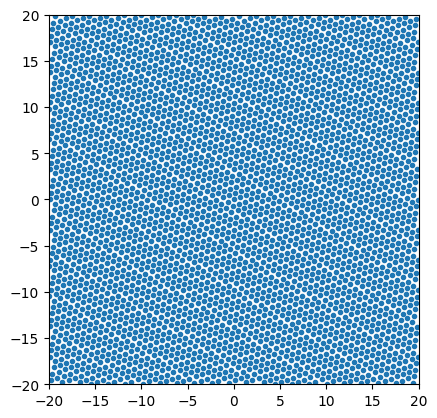

In [160]:
plt.plot(x0, y0, '.')

plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.gca().set_aspect(1)

In [162]:
img.psfm.shape, x0.size, img.image_ROI.shape

((106, 106, 3669), 3669, (106, 106))

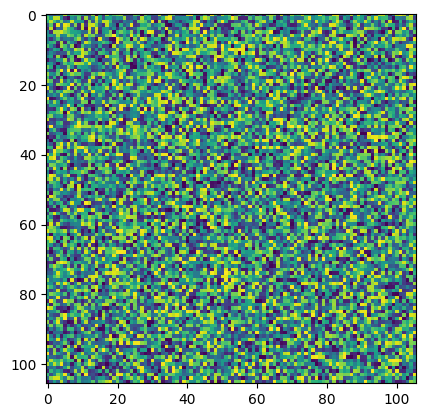

In [164]:
plt.imshow(img.image_ROI)

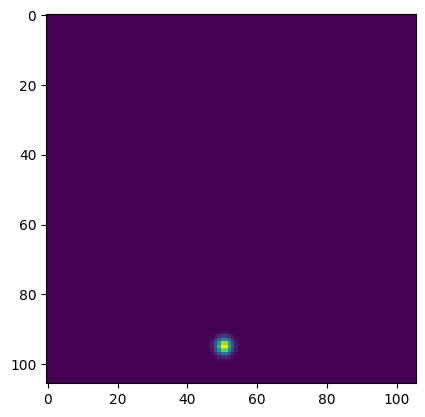

In [183]:
plt.imshow(img.psfm[:, :, -498-8])

In [ ]:
lx = np.arange(0, 512 - 512/2)
ly = np.arange(0, 512 - 512/2)



In [ ]:
x0s = np.random.random(100)
y0s = np.random.random(100)

psfm_size = np.array((self.xymesh_ROI[0].shape[0], self.xymesh_ROI[0].shape[1], x0s.size), dtype=np.uint16)


In [ ]:

---
## Matrix Generation Function (CPU)
---
def create_symmetric_matrix_np(param_a, param_b, size):
    """
    Creates a symmetric tridiagonal matrix using NumPy.

    Args:
        param_a (float): Parameter for the main diagonal elements.
        param_b (float): Parameter for the off-diagonal elements.
        size (int): The dimension of the square matrix (size x size).

    Returns:
        np.ndarray: A symmetric tridiagonal matrix.
    """
    diag = np.arange(size, dtype=np.float32) * param_a
    off_diag = np.ones(size - 1, dtype=np.float32) * param_b
    matrix = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
    return matrix

---
## Eigenvalue Problem Solver Functions
---

# CPU (NumPy) Solver
def solve_eigenvalue_problem_cpu(batched_matrices_np):
    """
    Solves eigenvalue problems for a batch of symmetric matrices using NumPy.

    Args:
        batched_matrices_np (np.ndarray): A 3D NumPy array of shape (num_batches, size, size).

    Returns:
        tuple: (eigenvalues, eigenvectors) as NumPy arrays.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(batched_matrices_np)
    return eigenvalues, eigenvectors

# GPU (CuPy) Solver
def solve_eigenvalue_problem_gpu(batched_matrices_gpu):
    """
    Solves eigenvalue problems for a batch of symmetric matrices using CuPy.

    Args:
        batched_matrices_gpu (cp.ndarray): A 3D CuPy array of shape (num_batches, size, size).

    Returns:
        tuple: (eigenvalues, eigenvectors) as CuPy arrays.
    """
    eigenvalues, eigenvectors = cp.linalg.eigh(batched_matrices_gpu)
    return eigenvalues, eigenvectors

---
## Performance Comparison Function
---
def run_performance_test(matrix_size, num_batches):
    """
    Runs a performance comparison test between NumPy (CPU) and CuPy (GPU)
    for solving eigenvalue problems on batches of matrices.

    Args:
        matrix_size (int): The dimension of each square matrix.
        num_batches (int): The number of matrices in the batch.
    """
    print(f"\n--- Performance Comparison Test ---")
    print(f"    Matrix size: {matrix_size}x{matrix_size}")
    print(f"    Number of batches: {num_batches}")

    # Prepare parameters on CPU
    params_a = np.linspace(1.0, 2.0, num_batches, dtype=np.float32)
    params_b = np.linspace(0.1, 0.5, num_batches, dtype=np.float32)

    # 1. Execute on CPU (NumPy)
    print("\n[Running on CPU (NumPy)...]")
    start_time_cpu = time.time()

    batched_matrices_cpu = np.array([
        create_symmetric_matrix_np(a, b, matrix_size)
        for a, b in zip(params_a, params_b)
    ])

    e_vals_cpu, e_vecs_cpu = solve_eigenvalue_problem_cpu(batched_matrices_cpu)

    end_time_cpu = time.time()
    cpu_time = end_time_cpu - start_time_cpu
    print(f"    CPU (NumPy) execution time: {cpu_time:.4f} seconds")

    # 2. Execute on GPU (CuPy)
    if num_gpus > 0:
        print("\n[Running on GPU (CuPy)...]")
        start_time_gpu = time.time()

        # Transfer data to GPU
        batched_matrices_gpu = cp.asarray(batched_matrices_cpu)

        e_vals_gpu, e_vecs_gpu = solve_eigenvalue_problem_gpu(batched_matrices_gpu)

        # Wait for all GPU computations to finish
        cp.cuda.Stream.null.synchronize()

        end_time_gpu = time.time()
        gpu_time = end_time_gpu - start_time_gpu
        print(f"    GPU (CuPy) execution time: {gpu_time:.4f} seconds")

        # Performance comparison
        if gpu_time == 0.0:
            # If GPU time is negligible, indicate it's significantly faster
            print("    **GPU is extremely fast; computation completed in measurable time (GPU is faster than CPU).**")
            print(f"    Compared to CPU time ({cpu_time:.4f} seconds), GPU is instantaneous.")
        elif cpu_time == 0.0:
            # If CPU time is also negligible (for very small computations)
            print("    **Both CPU and GPU are extremely fast; computation completed in measurable time (both instantaneous).**")
        elif gpu_time < cpu_time:
            speedup = cpu_time / gpu_time
            print(f"    **GPU is {speedup:.2f} times faster than CPU!**")
        else:
            speedup = gpu_time / cpu_time
            print(f"    **CPU is {speedup:.2f} times faster than GPU.**")

        # Optional: check for numerical consistency of results
        # print(f"    Result consistency (eigenvalues): {np.allclose(e_vals_cpu, cp.asnumpy(e_vals_gpu), atol=1e-5)}")
    else:
        print("\nNo GPU detected, skipping CuPy comparison.")

---
## Test Execution
---
# Let's try with various matrix sizes and batch counts

# Case 1: Small matrices, few batches (GPU overhead might be noticeable)
run_performance_test(matrix_size=100, num_batches=1)

# Case 2: Small matrices, many batches (GPU parallelism might start to kick in)
run_performance_test(matrix_size=100, num_batches=100)

# Case 3: Medium matrices, few batches
run_performance_test(matrix_size=500, num_batches=1)

# Case 4: Medium matrices, many batches (GPU's true potential might start to show)
run_performance_test(matrix_size=500, num_batches=100)

# Case 5: Large matrices, few batches (GPU might show a clear advantage)
run_performance_test(matrix_size=1000, num_batches=1)

# Case 6: Large matrices, many batches (GPU might be significantly advantageous)
run_performance_test(matrix_size=1000, num_batches=100)

# You can also try even larger matrices (be mindful of memory usage)
# run_performance_test(matrix_size=2000, num_batches=10)